# Unsynchronized SpikeIMU / Board timeline notebook

This notebook is converted from the plotting script and keeps the same **unsynchronized** timestamp contract.

Execution order:
1. Load the SpikeIMU feature input.
2. Plot raw SpikeIMU columns **15:21** first:
   - columns 15, 16, 17: accel X/Y/Z, three lines in one figure;
   - columns 18, 19, 20: gyro X/Y/Z, three lines in one figure;
   - each figure covers one 10-second window.
3. Compute the transient score from the same SpikeIMU transient channels.
4. Plot transient score in 10-second windows, with raw labels and raw Board press/lift timestamps overlaid.

Board press is red, Board lift is gold, and the transient score is light/thin. No Ring↔Board alignment offset is applied.

In [107]:
import math
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np

from writingring.board_loader import load_board
from writingring.discovery import discover_recordings
from writingring.event_alignment import compute_transient_score_array
from writingring.recording_features import load_recording_features
from writingring.segmentation import load_timestamp_labels
from writingring.selection import select_recording

# Notebook 位于 <project>/notebooks/ 时，自动找到项目根目录
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_ROOT = PROJECT_ROOT / "data"

USER = "user_10"
ACTION = "0"
DATASET_ID = 0

SPIKE_ROOT = (
    PROJECT_ROOT
    / "outputs/action0_rectified/low-pass/"
      "aligned-board-events/spikeEncoding/custom-wavelet"
)

PANEL_SECONDS = 10.0
XLIM_SOURCE = "union"
DPI = 200
OVERWRITE = True
SAVE_FIGURES = True
OUTPUT_DIR = PROJECT_ROOT / "outputs/diagnostics/unsynced_spikeimu_timeline"

ACCEL_INDICES = (15, 16, 17)
GYRO_INDICES = (18, 19, 20)
RAW_TRANSIENT_SLICE = slice(15, 21)

def seconds_from_ring_start(timestamps_us, ring_start_us: float) -> np.ndarray:
    values = np.asarray(timestamps_us, dtype=np.float64)
    return (values - ring_start_us) / 1_000_000.0

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_ROOT:", DATA_ROOT)
print("DATA_ROOT exists:", DATA_ROOT.exists())
print("SPIKE_ROOT:", SPIKE_ROOT)
print("SPIKE_ROOT exists:", SPIKE_ROOT.exists())

recordings = discover_recordings(DATA_ROOT)

available = [
    r for r in recordings
    if r.user == USER and str(r.action) == str(ACTION)
]

if not available:
    raise ValueError(
        f"No recordings found for USER={USER!r}, ACTION={ACTION!r}"
    )

available_ids = sorted(r.dataset_id for r in available)

print(
    f"Available dataset IDs for USER={USER!r}, ACTION={ACTION!r}: "
    f"{available_ids}"
)

if DATASET_ID not in available_ids:
    raise ValueError(
        f"DATASET_ID={DATASET_ID} is unavailable. "
        f"Choose one of: {available_ids}"
    )

recording = select_recording(
    recordings,
    user=USER,
    action=str(ACTION),
    dataset_id=DATASET_ID,
)

if recording.timestamp_path is None:
    raise ValueError(
        f"dataset {DATASET_ID} has no timestamp label file"
    )

feature_input = load_recording_features(
    recording,
    input_kind="spike-imu",
    spike_root=SPIKE_ROOT,
)

spike_values = np.asarray(feature_input.values)
ring_timestamps_us = np.asarray(
    feature_input.timestamps_us,
    dtype=np.float64,
)

if spike_values.ndim != 2:
    raise ValueError(
        f"expected 2-D SpikeIMU values, got shape={spike_values.shape}"
    )

if spike_values.shape[0] != ring_timestamps_us.shape[0]:
    raise ValueError(
        "SpikeIMU row count does not match timestamp count"
    )

if spike_values.shape[1] < RAW_TRANSIENT_SLICE.stop:
    raise ValueError(
        f"SpikeIMU has only {spike_values.shape[1]} columns; "
        "columns 15:21 are unavailable"
    )

ring_start_us = float(ring_timestamps_us[0])
ring_seconds = seconds_from_ring_start(
    ring_timestamps_us,
    ring_start_us,
)

print()
print(f"Selected recording: {recording}")
print(f"SpikeIMU shape: {spike_values.shape}")
print(
    "Canonical timestamp range: "
    f"{ring_timestamps_us[0]:.0f} .. "
    f"{ring_timestamps_us[-1]:.0f} us"
)
print(
    "Transient channel indices reported by loader: "
    f"{tuple(feature_input.transient_channel_indices)}"
)
print(
    "Raw columns requested for inspection: "
    f"{tuple(range(15, 21))}"
)

PROJECT_ROOT: /home/ted/project/writingRing
DATA_ROOT: /home/ted/project/writingRing/data
DATA_ROOT exists: True
SPIKE_ROOT: /home/ted/project/writingRing/outputs/action0_rectified/low-pass/aligned-board-events/spikeEncoding/custom-wavelet
SPIKE_ROOT exists: True
Available dataset IDs for USER='user_10', ACTION='0': [0, 1, 2, 3, 4, 5]

Selected recording: Recording(user='user_10', action='0', dataset_id=0, ring_0_path=PosixPath('/home/ted/project/writingRing/data/user_10/0/0_ring_0.bin'), ring_1_path=PosixPath('/home/ted/project/writingRing/data/user_10/0/0_ring_1.bin'), timestamp_path=PosixPath('/home/ted/project/writingRing/data/user_10/0/0_timestamp.txt'), board_chunk_paths=(PosixPath('/home/ted/project/writingRing/data/user_10/0/0_board_0.gz'), PosixPath('/home/ted/project/writingRing/data/user_10/0/0_board_1.gz'), PosixPath('/home/ted/project/writingRing/data/user_10/0/0_board_2.gz'), PosixPath('/home/ted/project/writingRing/data/user_10/0/0_board_3.gz'), PosixPath('/home/ted/proj

In [108]:
from writingring.board_loader import load_board
from writingring.discovery import discover_recordings
from writingring.event_alignment import compute_transient_score_array
from writingring.recording_features import load_recording_features
from writingring.segmentation import load_timestamp_labels
from writingring.selection import select_recording


In [109]:
def seconds_from_ring_start(timestamps_us, ring_start_us: float) -> np.ndarray:
    values = np.asarray(timestamps_us, dtype=np.float64)
    return (values - ring_start_us) / 1_000_000.0


def inside_window(values: np.ndarray, start: float, stop: float, *, final: bool) -> np.ndarray:
    if final:
        return (values >= start) & (values <= stop)
    return (values >= start) & (values < stop)


def ring_windows(ring_seconds: np.ndarray, panel_seconds: float = PANEL_SECONDS):
    start = math.floor(float(ring_seconds[0]) / panel_seconds) * panel_seconds
    stop = math.ceil(float(ring_seconds[-1]) / panel_seconds) * panel_seconds
    if stop <= start:
        stop = start + panel_seconds
    count = max(1, int(math.ceil((stop - start) / panel_seconds)))
    return [(start + i * panel_seconds, start + (i + 1) * panel_seconds) for i in range(count)]


def transient_windows(
    ring_seconds: np.ndarray,
    label_seconds: np.ndarray,
    board_seconds: np.ndarray,
    panel_seconds: float = PANEL_SECONDS,
    source: str = XLIM_SOURCE,
):
    if source == "ring":
        minimum = float(ring_seconds[0])
        maximum = float(ring_seconds[-1])
    elif source == "union":
        parts = [ring_seconds]
        if label_seconds.size:
            parts.append(label_seconds)
        if board_seconds.size:
            parts.append(board_seconds)
        all_seconds = np.concatenate(parts)
        minimum = float(np.min(all_seconds))
        maximum = float(np.max(all_seconds))
    else:
        raise ValueError("source must be 'union' or 'ring'")

    start = math.floor(minimum / panel_seconds) * panel_seconds
    stop = math.ceil(maximum / panel_seconds) * panel_seconds
    if stop <= start:
        stop = start + panel_seconds
    count = max(1, int(math.ceil((stop - start) / panel_seconds)))
    return [(start + i * panel_seconds, start + (i + 1) * panel_seconds) for i in range(count)]


def raw_board_transitions(board_frames):
    """Detect raw occupancy transitions only; do not pair/classify touches."""
    import pandas as pd

    required = {"frame_timestamp_raw", "contact_count", "global_frame_index"}
    missing = sorted(required - set(board_frames.columns))
    if missing:
        raise ValueError("Board frames are missing required columns: " + ", ".join(missing))

    if board_frames.empty:
        return pd.DataFrame(
            columns=("event_index", "event_type", "global_frame_index", "frame_timestamp_raw")
        )

    contact_count = board_frames["contact_count"].to_numpy(dtype=np.int64)
    occupied_i8 = (contact_count > 0).astype(np.int8)
    transition = np.diff(occupied_i8, prepend=occupied_i8[0])
    positions = np.flatnonzero(transition != 0)

    rows = []
    for event_index, position in enumerate(positions):
        frame = board_frames.iloc[int(position)]
        rows.append(
            {
                "event_index": event_index,
                "event_type": "press" if transition[int(position)] == 1 else "lift",
                "global_frame_index": int(frame["global_frame_index"]),
                "frame_timestamp_raw": float(frame["frame_timestamp_raw"]),
            }
        )
    return pd.DataFrame(rows)


def save_or_show(fig, filename: str):
    if SAVE_FIGURES:
        output_path = OUTPUT_DIR / filename
        output_path.parent.mkdir(parents=True, exist_ok=True)
        if output_path.exists() and not OVERWRITE:
            raise FileExistsError(f"output exists and overwrite is disabled: {output_path}")
        fig.savefig(output_path, dpi=DPI, bbox_inches="tight")
        print(f"Saved: {output_path}")
    plt.show()
    plt.close(fig)


## 1. Select recording and load SpikeIMU

The raw channel plots below happen immediately after `load_recording_features(...)`, before the transient score is computed.

In [110]:
recording = select_recording(
    discover_recordings(DATA_ROOT),
    user=USER,
    action=str(ACTION),
    dataset_id=DATASET_ID,
)

if recording.timestamp_path is None:
    raise ValueError(f"dataset {DATASET_ID} has no timestamp label file")

feature_input = load_recording_features(
    recording,
    input_kind="spike-imu",
    spike_root=SPIKE_ROOT,
)

spike_values = np.asarray(feature_input.values)
ring_timestamps_us = np.asarray(feature_input.timestamps_us, dtype=np.float64)

if spike_values.ndim != 2:
    raise ValueError(f"expected 2-D SpikeIMU values, got shape={spike_values.shape}")
if spike_values.shape[0] != ring_timestamps_us.shape[0]:
    raise ValueError("SpikeIMU row count does not match timestamp count")
if spike_values.shape[1] < RAW_TRANSIENT_SLICE.stop:
    raise ValueError(
        f"SpikeIMU has only {spike_values.shape[1]} columns; columns 15:21 are unavailable"
    )

ring_start_us = float(ring_timestamps_us[0])
ring_seconds = seconds_from_ring_start(ring_timestamps_us, ring_start_us)

print(f"SpikeIMU shape: {spike_values.shape}")
print(f"Canonical timestamp range: {ring_timestamps_us[0]:.0f} .. {ring_timestamps_us[-1]:.0f} us")
print(f"Transient channel indices reported by loader: {tuple(feature_input.transient_channel_indices)}")
print(f"Raw columns requested for inspection: {tuple(range(15, 21))}")


SpikeIMU shape: (13153, 21)
Canonical timestamp range: 1720390007771631 .. 1720390073176308 us
Transient channel indices reported by loader: (15, 16, 17, 18, 19, 20)
Raw columns requested for inspection: (15, 16, 17, 18, 19, 20)


## 2. Plot accel X/Y/Z — one figure per 10 seconds

Columns 15, 16, 17 are plotted together in each 10-second window.

Saved: /home/ted/project/writingRing/outputs/diagnostics/unsynced_spikeimu_timeline/accel_xyz_000000.0_000010.0s.png


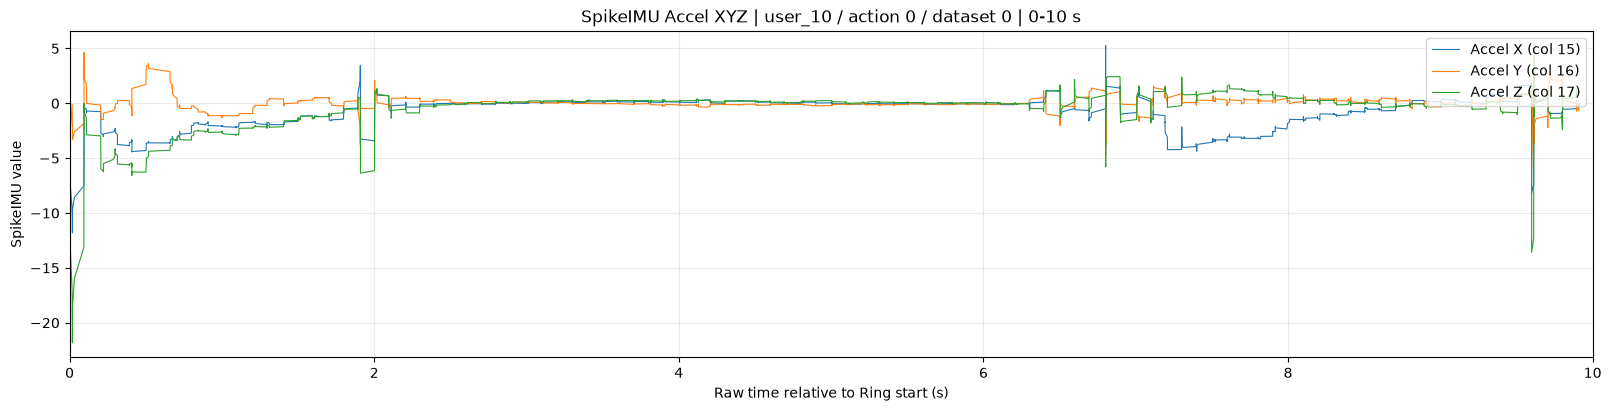

Saved: /home/ted/project/writingRing/outputs/diagnostics/unsynced_spikeimu_timeline/accel_xyz_000010.0_000020.0s.png


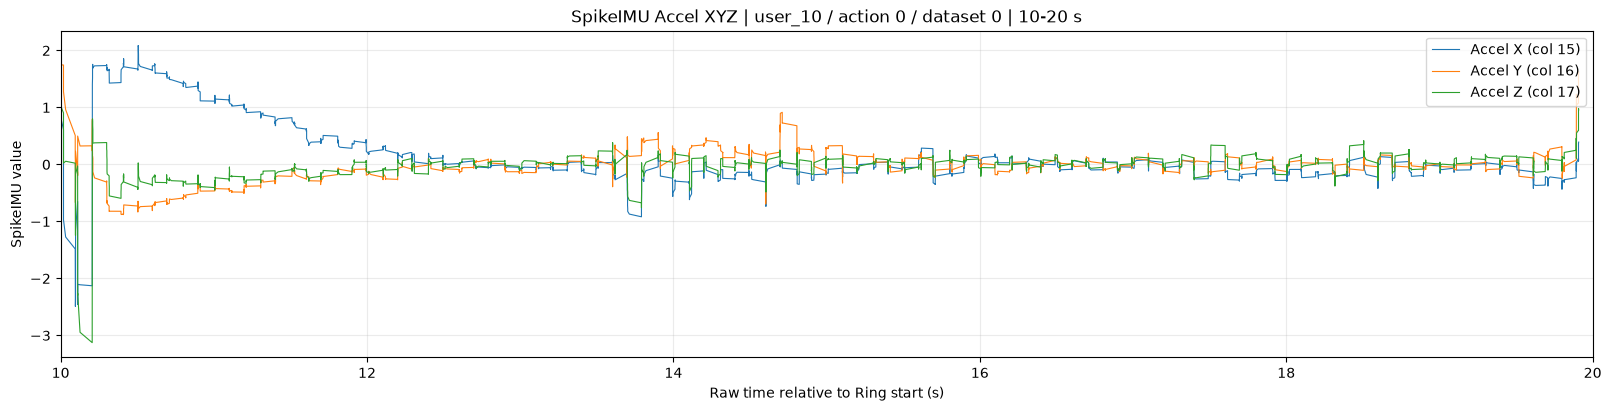

Saved: /home/ted/project/writingRing/outputs/diagnostics/unsynced_spikeimu_timeline/accel_xyz_000020.0_000030.0s.png


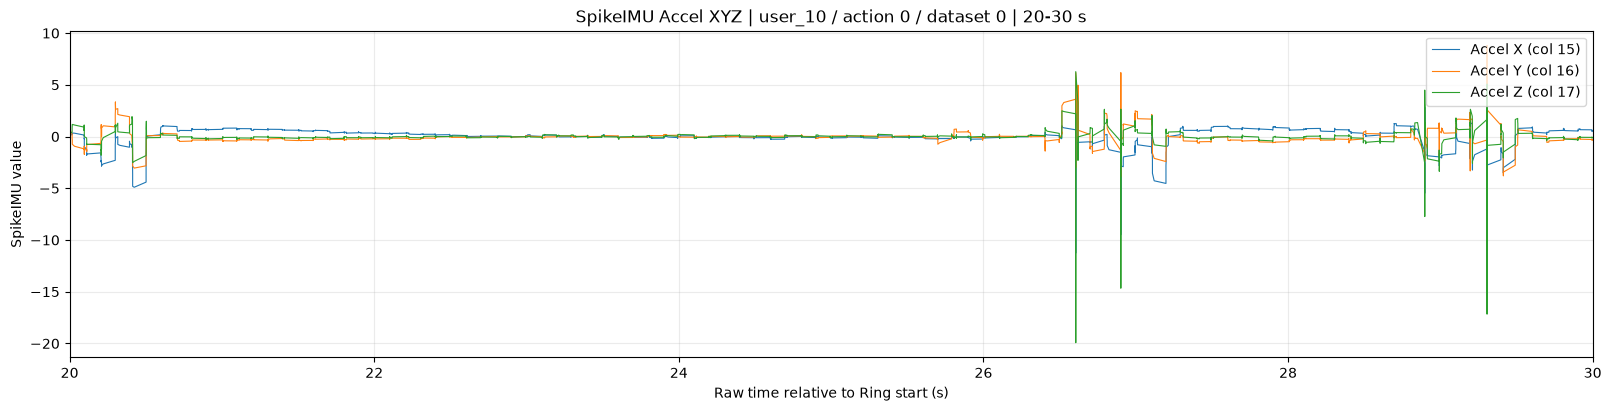

Saved: /home/ted/project/writingRing/outputs/diagnostics/unsynced_spikeimu_timeline/accel_xyz_000030.0_000040.0s.png


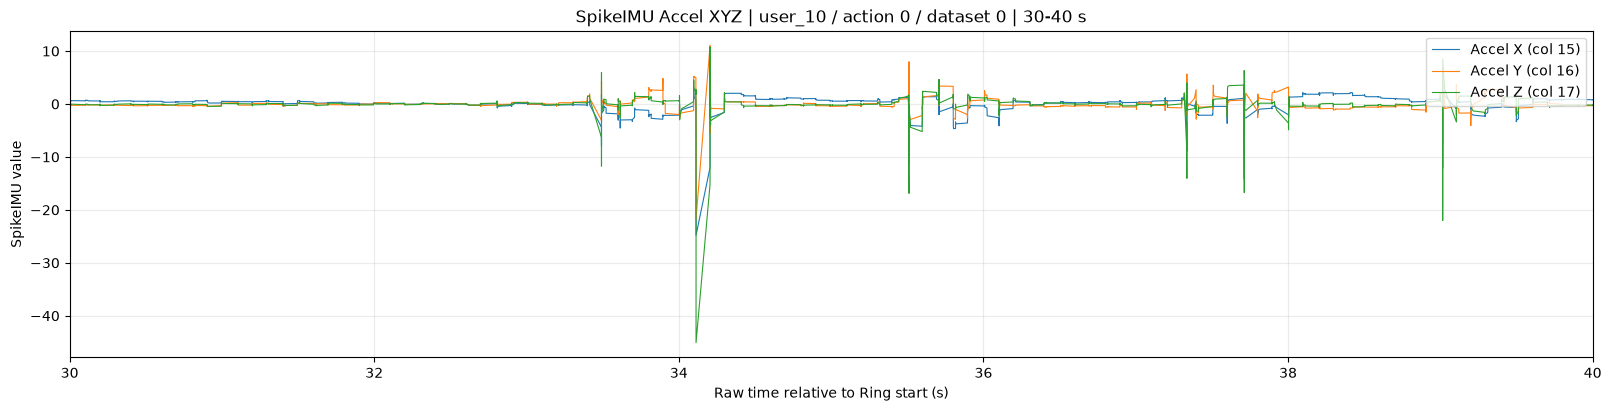

Saved: /home/ted/project/writingRing/outputs/diagnostics/unsynced_spikeimu_timeline/accel_xyz_000040.0_000050.0s.png


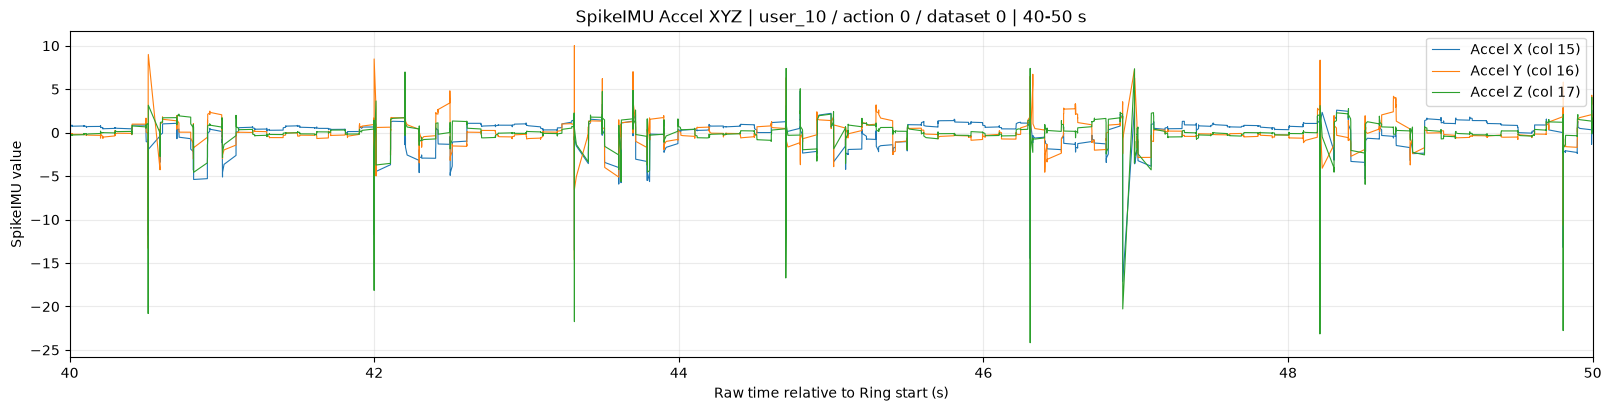

Saved: /home/ted/project/writingRing/outputs/diagnostics/unsynced_spikeimu_timeline/accel_xyz_000050.0_000060.0s.png


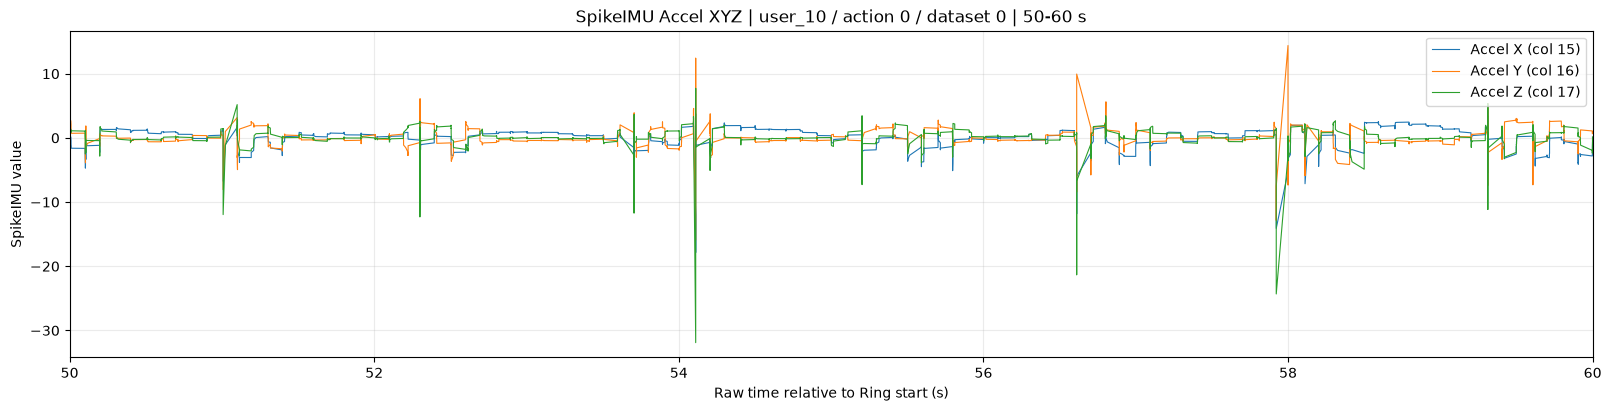

Saved: /home/ted/project/writingRing/outputs/diagnostics/unsynced_spikeimu_timeline/accel_xyz_000060.0_000070.0s.png


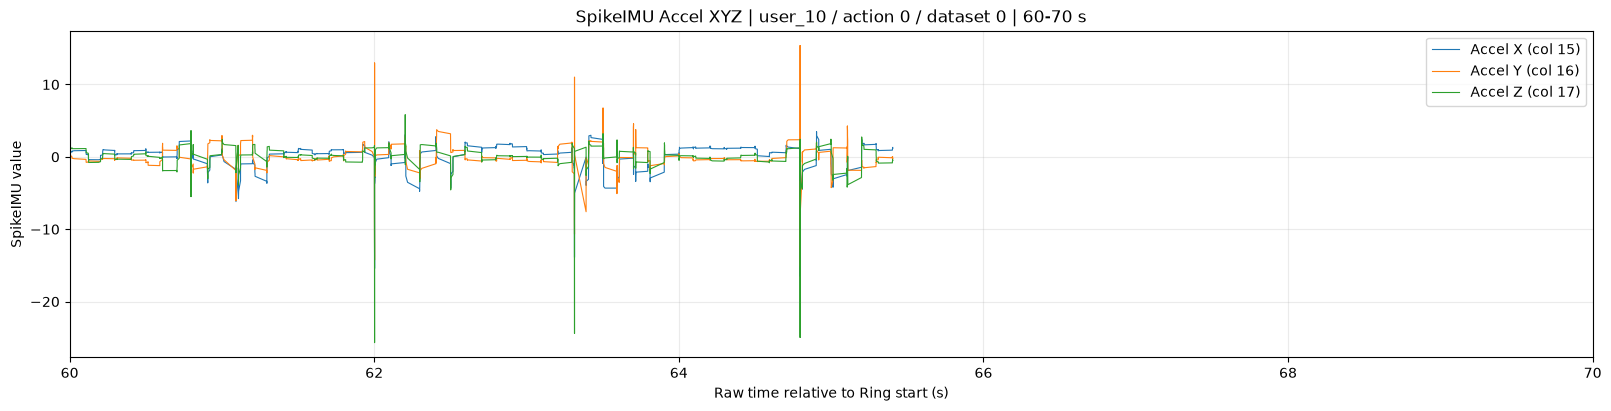

In [111]:
accel_values = spike_values[:, ACCEL_INDICES]
windows = ring_windows(ring_seconds, PANEL_SECONDS)

for window_index, (start, stop) in enumerate(windows):
    final = window_index == len(windows) - 1
    mask = inside_window(ring_seconds, start, stop, final=final)
    if not np.any(mask):
        continue

    fig, ax = plt.subplots(figsize=(16, 4), layout="constrained")
    for axis_index, axis_name in enumerate(("Accel X", "Accel Y", "Accel Z")):
        ax.plot(
            ring_seconds[mask],
            accel_values[mask, axis_index],
            linewidth=0.8,
            label=f"{axis_name} (col {ACCEL_INDICES[axis_index]})",
        )

    ax.set_xlim(start, stop)
    ax.set_title(
        f"SpikeIMU Accel XYZ | {USER} / action {ACTION} / dataset {DATASET_ID} | "
        f"{start:g}-{stop:g} s"
    )
    ax.set_xlabel("Raw time relative to Ring start (s)")
    ax.set_ylabel("SpikeIMU value")
    ax.grid(True, alpha=0.25)
    ax.legend(loc="upper right")

    save_or_show(fig, f"accel_xyz_{start:08.1f}_{stop:08.1f}s.png")


## 3. Plot gyro X/Y/Z — one figure per 10 seconds

Columns 18, 19, 20 are plotted together in each 10-second window.

Saved: /home/ted/project/writingRing/outputs/diagnostics/unsynced_spikeimu_timeline/gyro_xyz_000000.0_000010.0s.png


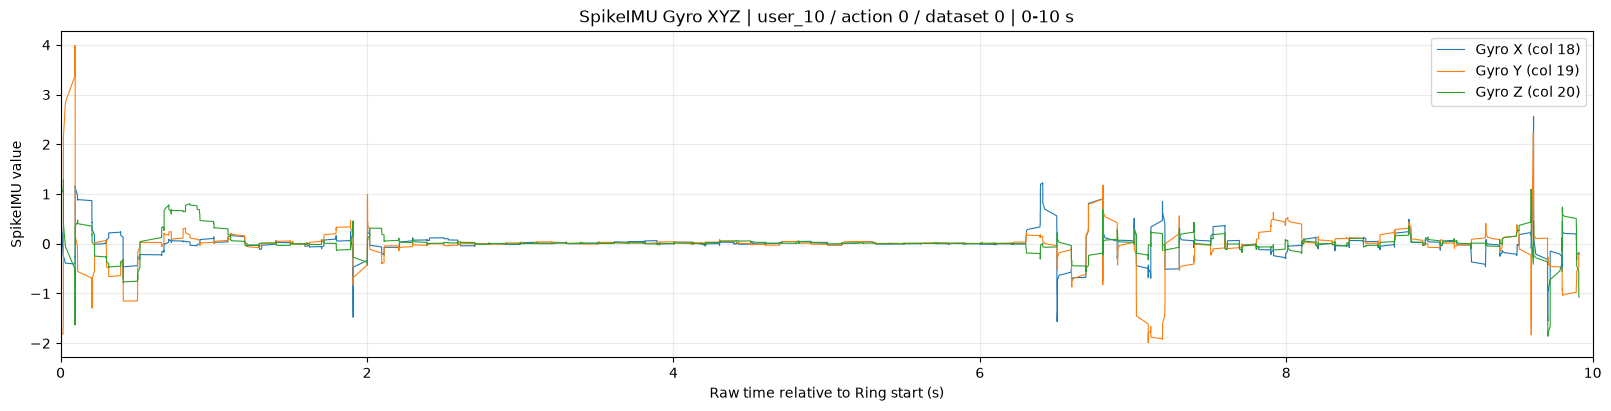

Saved: /home/ted/project/writingRing/outputs/diagnostics/unsynced_spikeimu_timeline/gyro_xyz_000010.0_000020.0s.png


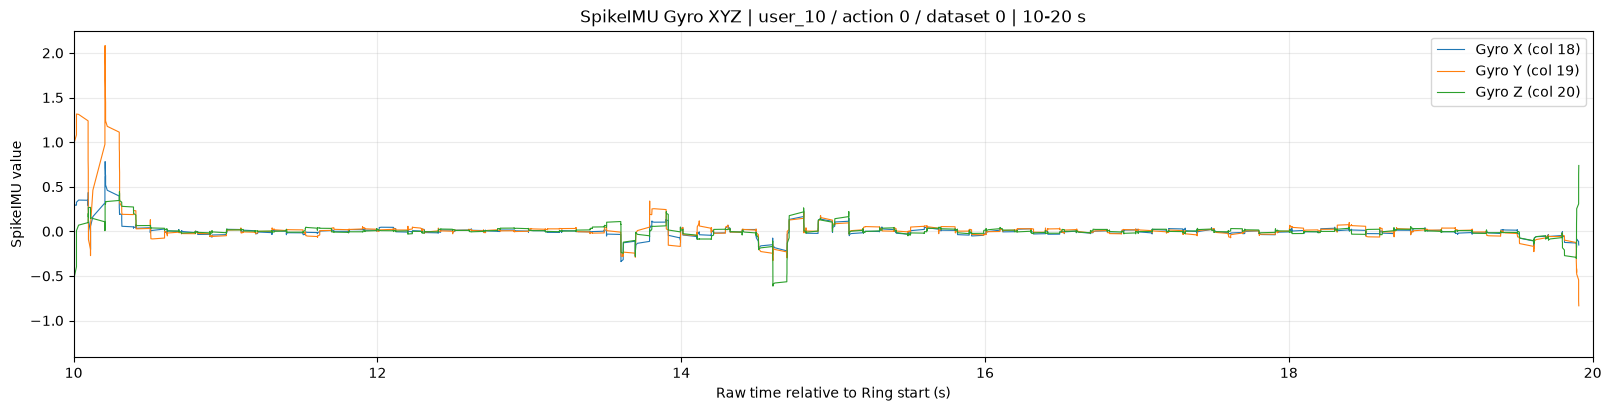

Saved: /home/ted/project/writingRing/outputs/diagnostics/unsynced_spikeimu_timeline/gyro_xyz_000020.0_000030.0s.png


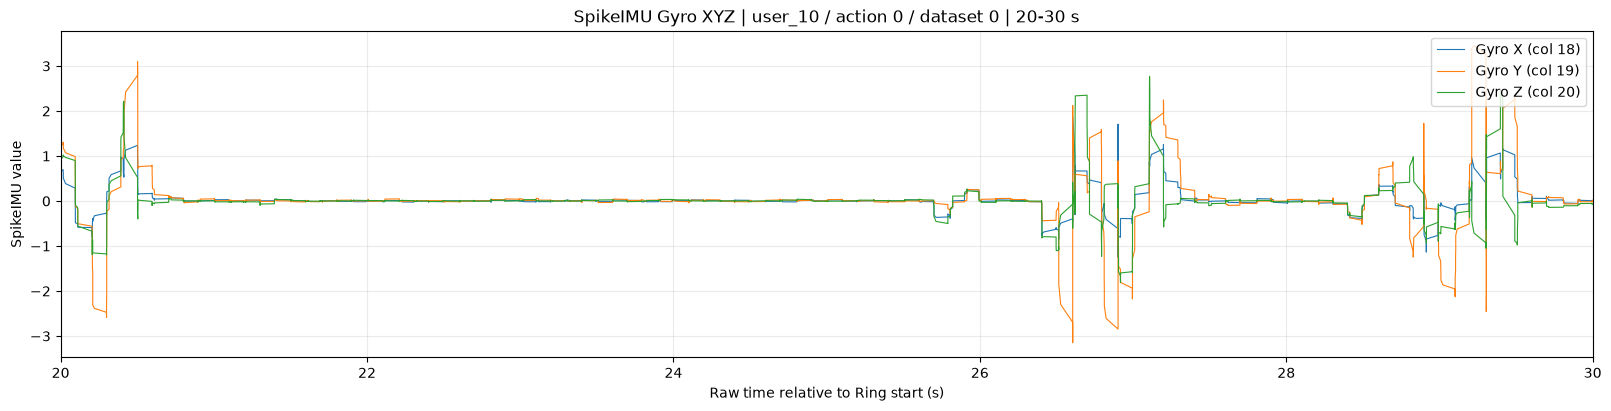

Saved: /home/ted/project/writingRing/outputs/diagnostics/unsynced_spikeimu_timeline/gyro_xyz_000030.0_000040.0s.png


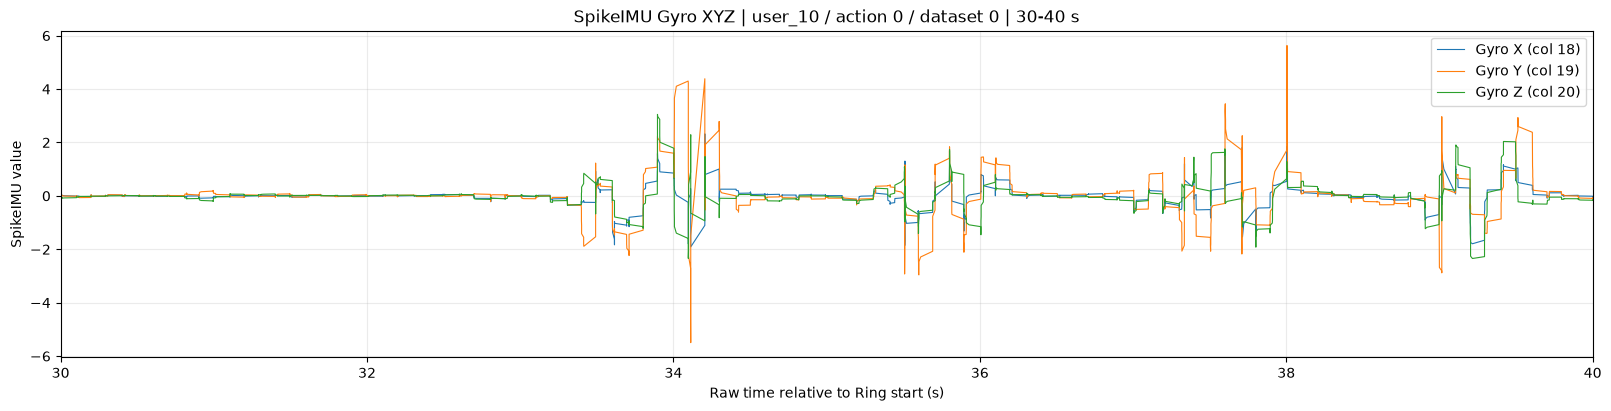

Saved: /home/ted/project/writingRing/outputs/diagnostics/unsynced_spikeimu_timeline/gyro_xyz_000040.0_000050.0s.png


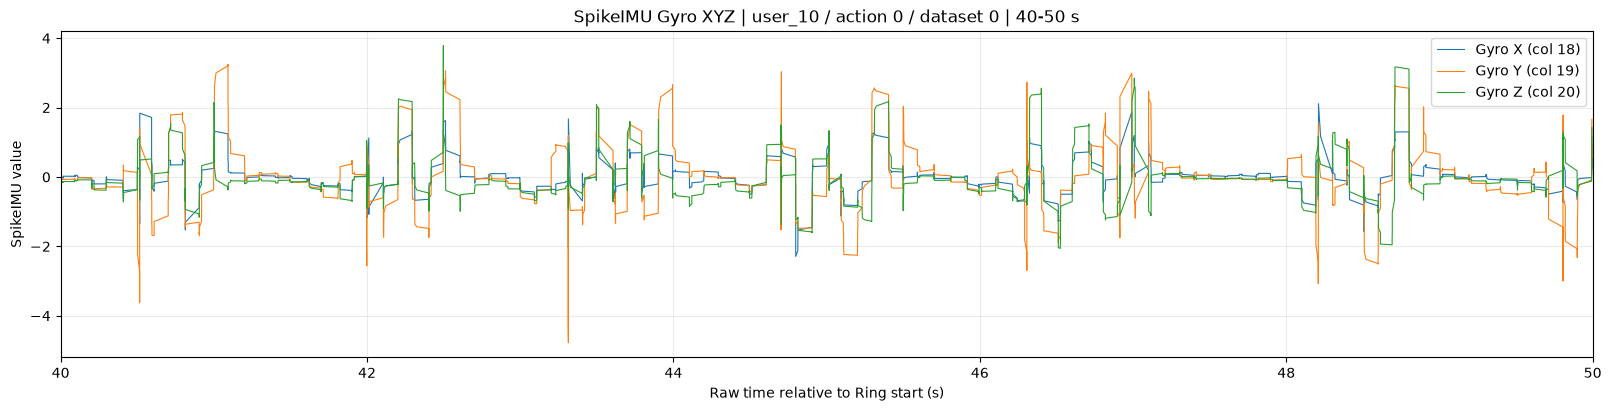

Saved: /home/ted/project/writingRing/outputs/diagnostics/unsynced_spikeimu_timeline/gyro_xyz_000050.0_000060.0s.png


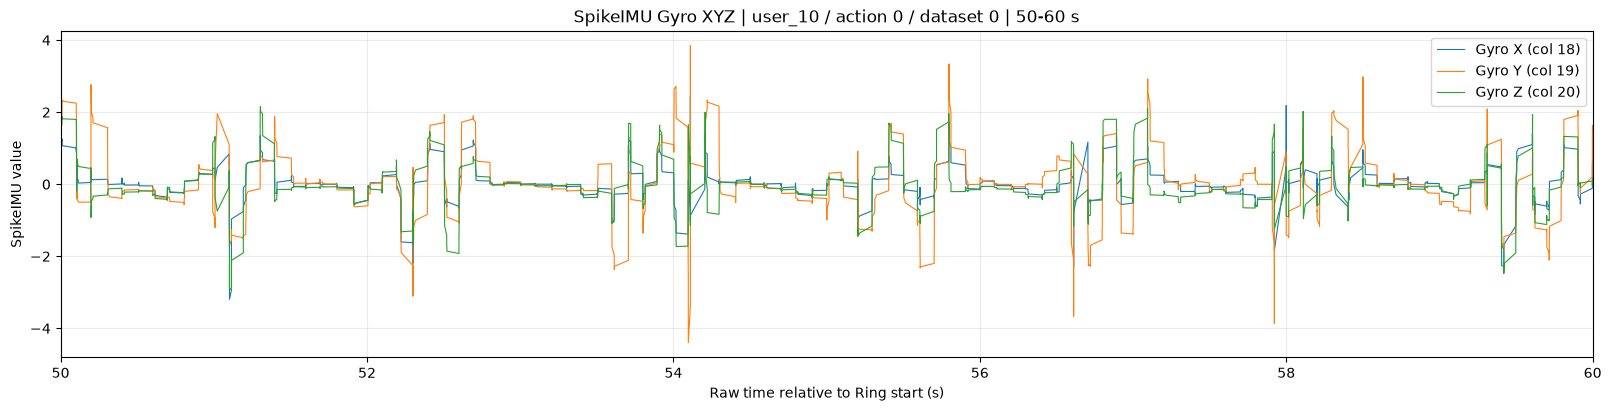

Saved: /home/ted/project/writingRing/outputs/diagnostics/unsynced_spikeimu_timeline/gyro_xyz_000060.0_000070.0s.png


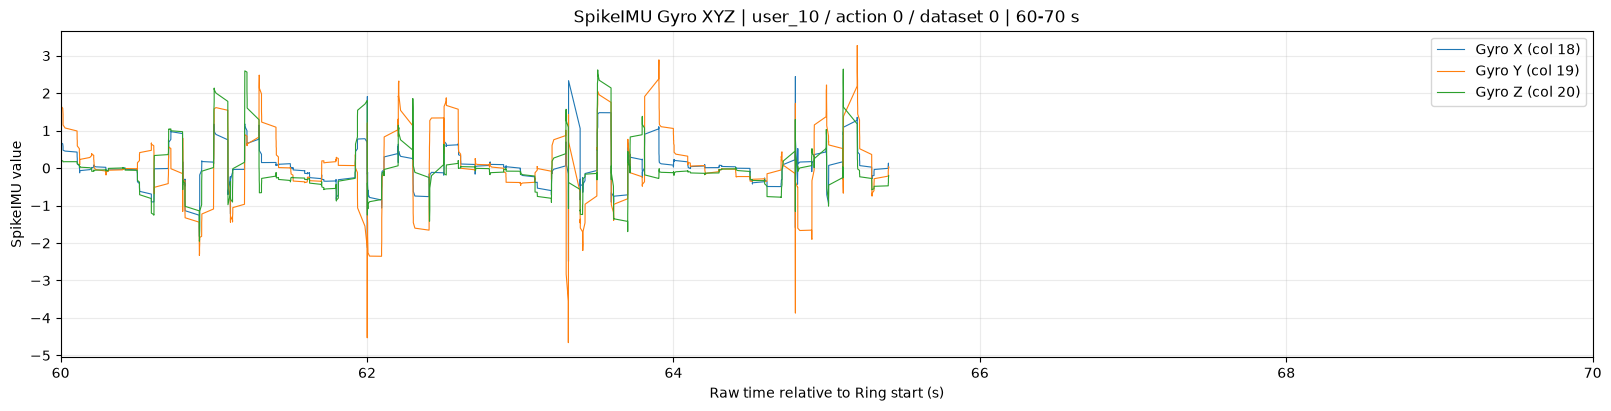

In [112]:
gyro_values = spike_values[:, GYRO_INDICES]

for window_index, (start, stop) in enumerate(windows):
    final = window_index == len(windows) - 1
    mask = inside_window(ring_seconds, start, stop, final=final)
    if not np.any(mask):
        continue

    fig, ax = plt.subplots(figsize=(16, 4), layout="constrained")
    for axis_index, axis_name in enumerate(("Gyro X", "Gyro Y", "Gyro Z")):
        ax.plot(
            ring_seconds[mask],
            gyro_values[mask, axis_index],
            linewidth=0.8,
            label=f"{axis_name} (col {GYRO_INDICES[axis_index]})",
        )

    ax.set_xlim(start, stop)
    ax.set_title(
        f"SpikeIMU Gyro XYZ | {USER} / action {ACTION} / dataset {DATASET_ID} | "
        f"{start:g}-{stop:g} s"
    )
    ax.set_xlabel("Raw time relative to Ring start (s)")
    ax.set_ylabel("SpikeIMU value")
    ax.grid(True, alpha=0.25)
    ax.legend(loc="upper right")

    save_or_show(fig, f"gyro_xyz_{start:08.1f}_{stop:08.1f}s.png")


## 4. Compute transient score

This is intentionally done **after** the raw accel/gyro inspection plots. The score uses the loader-provided `transient_channel_indices`, matching the original script.

In [ ]:
transient_channel_indices = tuple(feature_input.transient_channel_indices)

transient_score = compute_transient_score_array(
    feature_input.values[:, feature_input.transient_channel_indices]
)
transient_score = np.asarray(transient_score, dtype=np.float64)

if len(transient_score) != len(ring_timestamps_us):
    raise ValueError("transient score length does not match SpikeIMU timestamps")

print(f"Transient channels: {transient_channel_indices}")
print(f"Transient score shape: {transient_score.shape}")


Transient channels: (15, 16, 17)
Transient score shape: (13153,)


## 5. Load raw labels and raw Board transitions

These timestamps remain unsynchronized. Board transitions are detected directly from raw occupancy changes (`0 -> >0` press, `>0 -> 0` lift).

In [114]:
labels = load_timestamp_labels(recording.timestamp_path)
label_timestamps_us = np.asarray(
    [label.timestamp_us for label in labels],
    dtype=np.float64,
)

board = load_board(recording)
board_events = raw_board_transitions(board.frames)
board_timestamps_us = (
    board_events["frame_timestamp_raw"].to_numpy(dtype=np.float64)
    if len(board_events)
    else np.empty(0, dtype=np.float64)
)

label_seconds = seconds_from_ring_start(label_timestamps_us, ring_start_us)
board_seconds = seconds_from_ring_start(board_timestamps_us, ring_start_us)
board_event_types = (
    board_events["event_type"].to_numpy(dtype=object)
    if len(board_events)
    else np.empty(0, dtype=object)
)

press_count = int(np.sum(board_event_types == "press")) if len(board_event_types) else 0
lift_count = int(np.sum(board_event_types == "lift")) if len(board_event_types) else 0

print(f"Raw labels: {len(labels)}")
print(f"Raw Board transitions: press={press_count}, lift={lift_count}")
print("Alignment offset applied: NO")


Raw labels: 26
Raw Board transitions: press=32, lift=32
Alignment offset applied: NO


## 6. Plot transient score — one figure per 10 seconds

Style matches the updated script:
- transient score: light gray, thin;
- Board press: red;
- Board lift: gold;
- raw label timestamp: dashed vertical line with label text.

Saved: /home/ted/project/writingRing/outputs/diagnostics/unsynced_spikeimu_timeline/transient_000000.0_000010.0s.png


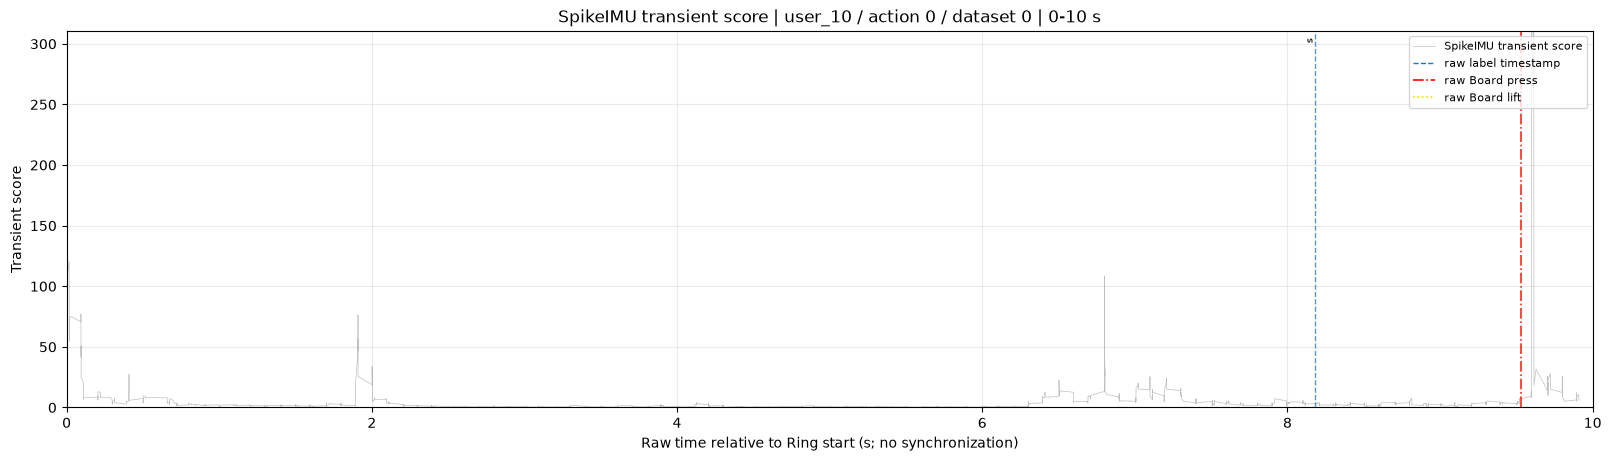

Saved: /home/ted/project/writingRing/outputs/diagnostics/unsynced_spikeimu_timeline/transient_000010.0_000020.0s.png


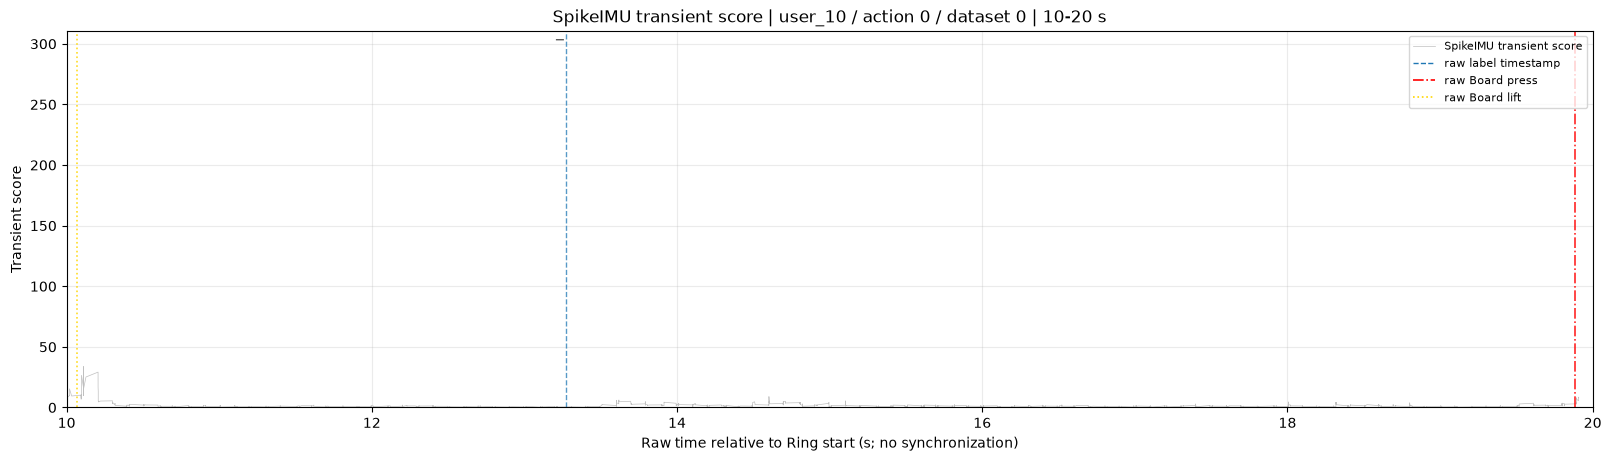

Saved: /home/ted/project/writingRing/outputs/diagnostics/unsynced_spikeimu_timeline/transient_000020.0_000030.0s.png


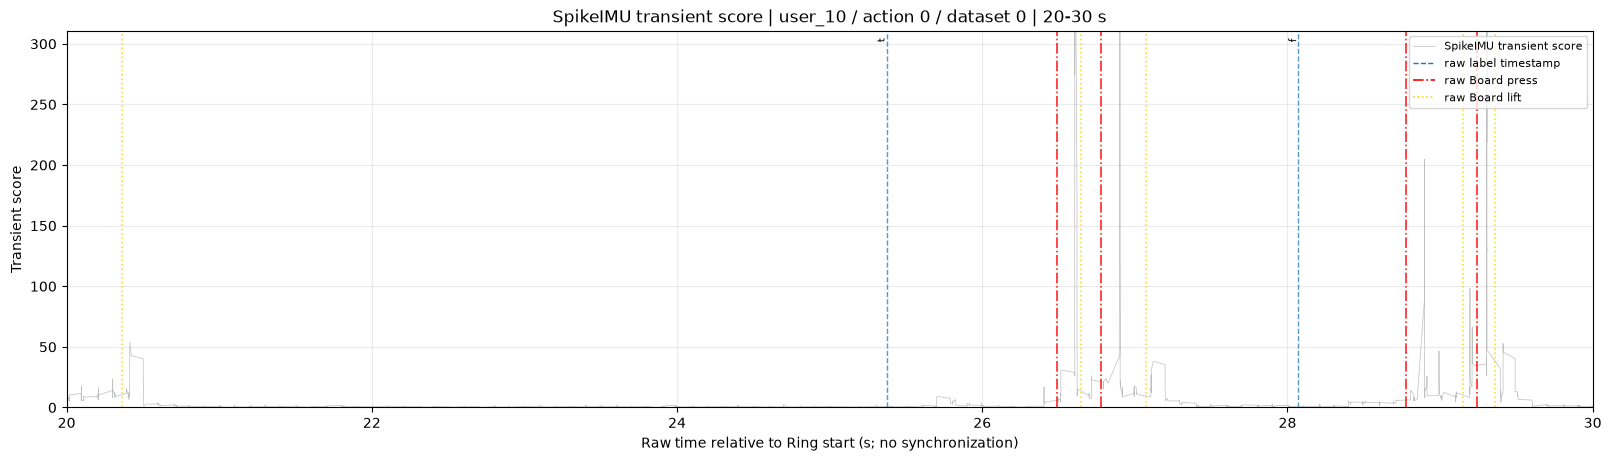

Saved: /home/ted/project/writingRing/outputs/diagnostics/unsynced_spikeimu_timeline/transient_000030.0_000040.0s.png


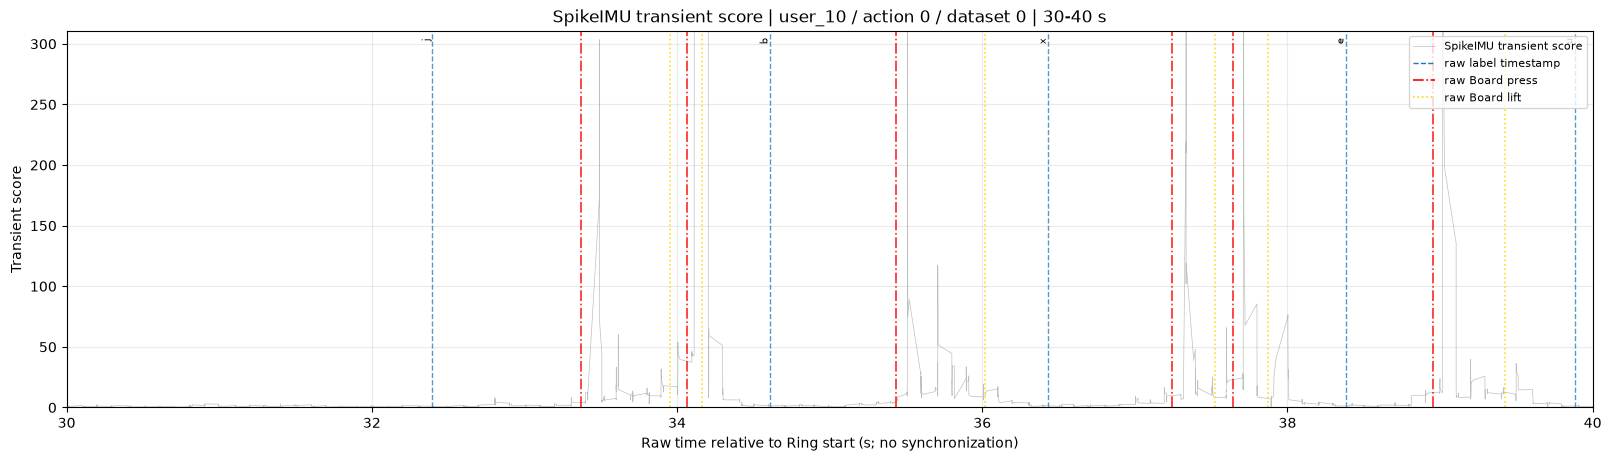

Saved: /home/ted/project/writingRing/outputs/diagnostics/unsynced_spikeimu_timeline/transient_000040.0_000050.0s.png


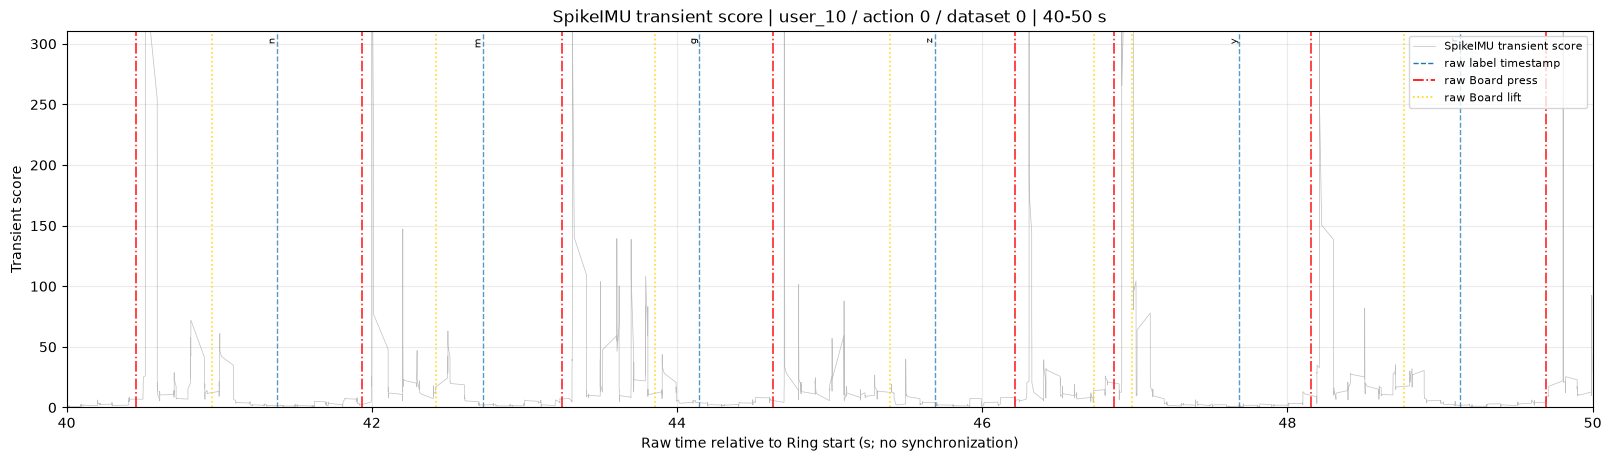

Saved: /home/ted/project/writingRing/outputs/diagnostics/unsynced_spikeimu_timeline/transient_000050.0_000060.0s.png


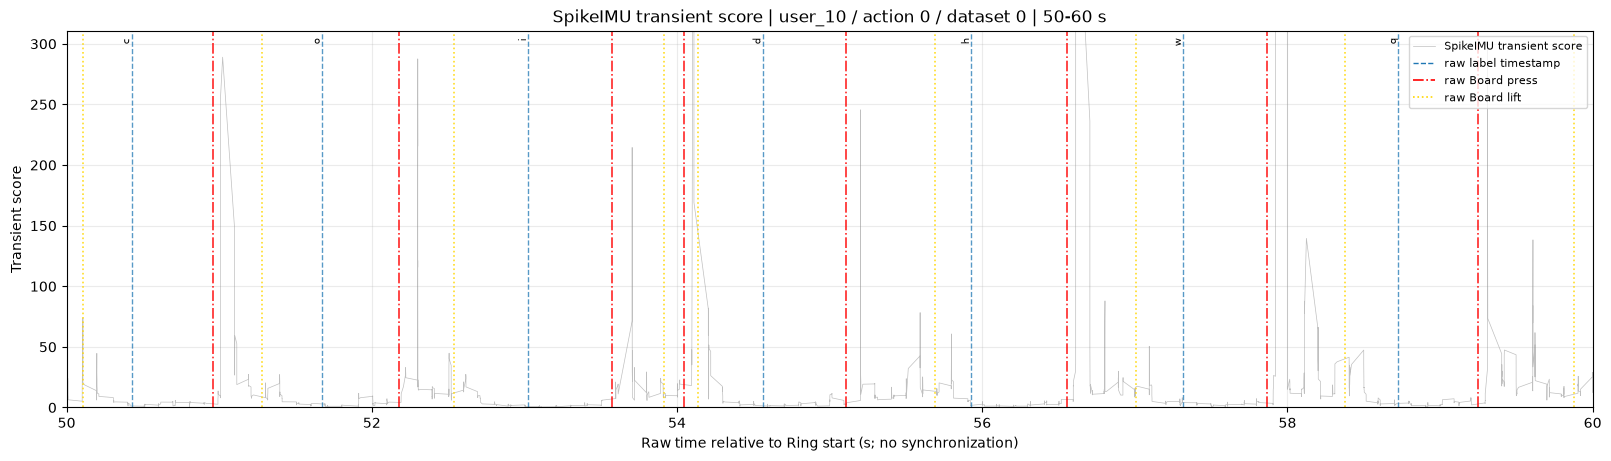

Saved: /home/ted/project/writingRing/outputs/diagnostics/unsynced_spikeimu_timeline/transient_000060.0_000070.0s.png


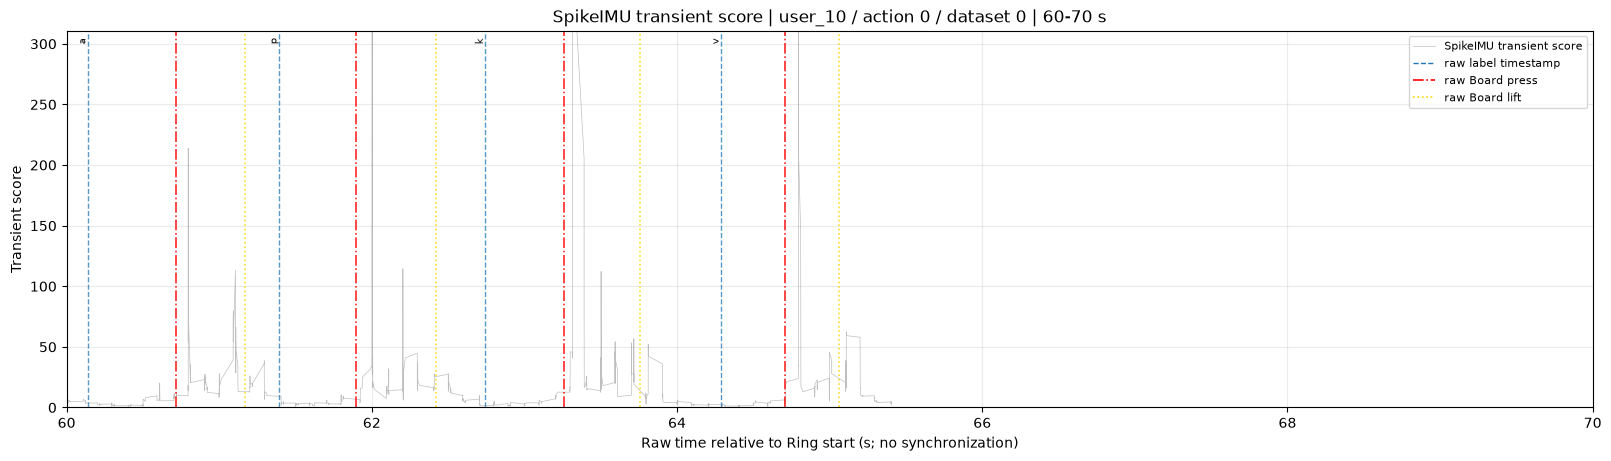

In [115]:
y_max = float(np.quantile(transient_score, 0.995) * 1.10)
if not math.isfinite(y_max) or y_max <= 0.0:
    y_max = max(float(np.max(transient_score)), 1.0)

score_windows = transient_windows(
    ring_seconds,
    label_seconds,
    board_seconds,
    panel_seconds=PANEL_SECONDS,
    source=XLIM_SOURCE,
)

for window_index, (start, stop) in enumerate(score_windows):
    final = window_index == len(score_windows) - 1

    ring_mask = inside_window(ring_seconds, start, stop, final=final)
    label_mask = inside_window(label_seconds, start, stop, final=final)
    board_mask = inside_window(board_seconds, start, stop, final=final)

    fig, ax = plt.subplots(figsize=(16, 4.5), layout="constrained")

    if np.any(ring_mask):
        ax.plot(
            ring_seconds[ring_mask],
            transient_score[ring_mask],
            color="0.55",
            linewidth=0.5,
            alpha=0.55,
        )

    for label_index in np.flatnonzero(label_mask):
        x = float(label_seconds[int(label_index)])
        ax.axvline(x, linestyle="--", linewidth=1.0, alpha=0.75)
        ax.text(
            x,
            y_max * 0.98,
            str(labels[int(label_index)].label),
            rotation=90,
            verticalalignment="top",
            horizontalalignment="right",
            fontsize=7,
            clip_on=True,
        )

    for board_index in np.flatnonzero(board_mask):
        event_type = str(board_event_types[int(board_index)])
        ax.axvline(
            float(board_seconds[int(board_index)]),
            color="red" if event_type == "press" else "gold",
            linestyle="-." if event_type == "press" else ":",
            linewidth=1.2,
            alpha=0.85,
        )

    ax.set_xlim(start, stop)
    ax.set_ylim(0.0, y_max)
    ax.grid(True, alpha=0.25)
    ax.set_title(
        f"SpikeIMU transient score | {USER} / action {ACTION} / dataset {DATASET_ID} | "
        f"{start:g}-{stop:g} s"
    )
    ax.set_xlabel("Raw time relative to Ring start (s; no synchronization)")
    ax.set_ylabel("Transient score")
    ax.legend(
        handles=[
            Line2D([], [], color="0.55", linestyle="-", linewidth=0.5, alpha=0.55,
                   label="SpikeIMU transient score"),
            Line2D([], [], linestyle="--", linewidth=1.0, label="raw label timestamp"),
            Line2D([], [], color="red", linestyle="-.", linewidth=1.2,
                   label="raw Board press"),
            Line2D([], [], color="gold", linestyle=":", linewidth=1.2,
                   label="raw Board lift"),
        ],
        loc="upper right",
        fontsize=8,
    )

    save_or_show(fig, f"transient_{start:08.1f}_{stop:08.1f}s.png")


## Notes

- `OVERWRITE = True` is the default, matching the requested overwrite behavior.
- Set `SAVE_FIGURES = False` if you only want inline notebook plots.
- The raw accel/gyro plots always use the canonical SpikeIMU/Ring time range.
- The transient-score plots use `XLIM_SOURCE = "union"` by default, so raw label/Board timestamps outside the Ring range are still visible, matching the original diagnostic behavior.
- No synchronization, offset, Board press/lift pairing, or Board transient classification is introduced.